
# Workspace Mapping Workflow (현재 디스크 구조 기준)

이 노트북은 **현재 RGMC 디스크 구조**에 맞춘 pixel → workspace 매핑 워크플로우입니다.

기준 구조:

```text
RGMC/
├─ notebooks/mapping/
├─ configs/calibration/
├─ configs/camera/
├─ data/map/
└─ src/
   ├─ calibration/
   ├─ common/camera/
   └─ cloudgripper_api/client/
```

핵심 원칙:
- `lut.pkl`은 **import 대상이 아니라 runtime data**입니다.
- 카메라 왜곡 보정은 `common.camera.calib_fisheye_cam`
- 매핑/LUT 관련 코드는 `calibration.*`
- 출력 결과는 `data/map/{robot}/`
- 토큰은 노트북에 쓰지 않고 `CLOUDGRIPPER_TOKEN` 환경 변수에서 읽습니다.


In [1]:
from pathlib import Path
import sys
import os
from dotenv import load_dotenv

# =========================
# Project Path Setup
# =========================

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]

SRC_ROOT = PROJECT_ROOT / "src"
CONFIG_ROOT = PROJECT_ROOT / "configs"
DATA_ROOT = PROJECT_ROOT / "data"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

# =========================
# .env Load
# =========================

env_path = PROJECT_ROOT / ".env"
print("env path:", env_path)
print("exists:", env_path.exists())

load_dotenv(env_path)

# 확인
if "CLOUDGRIPPER_TOKEN" not in os.environ:
    raise RuntimeError("CLOUDGRIPPER_TOKEN not found in .env")

print("Token loaded:", True)

PROJECT_ROOT: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC
env path: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\.env
exists: True
Token loaded: True


In [2]:

# 1. Imports: 현재 디스크 구조 기준
import os
import time
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cloudgripper_api.client.cloudgripper_client import GripperRobot
from common.camera.calib_fisheye_cam import undistort_image

from calibration.config import calibration_config_from_yaml
from calibration.camera_utils import load_camera_params, get_processed_base_image
from calibration.detector import YOLOGripperDetector
from calibration.collector import collect_calibration
from calibration.build_lookup_table import (
    parse_dataset,
    build_bidirectional_lookup,
    save_lookup_table,
)
from calibration.pixel_to_workspace import PixelToWorkspaceMapper
from calibration.visualize_workspace_grid import draw_grid_overlay, load_lut
from calibration.notebook_helpers import show_bgr, load_csv_preview, list_failed_points


## 1. 로봇 / 설정 선택

In [3]:

# 2. Robot / config / output 경로 설정
ROBOT_NAME = "robot29"   

ROBOT_ID = "".join(ch for ch in ROBOT_NAME if ch.isdigit())
if not ROBOT_ID:
    raise ValueError(f"ROBOT_NAME에서 robot id를 파싱하지 못했습니다: {ROBOT_NAME!r}")

CONFIG_PATH = CONFIG_ROOT / "calibration" / f"calibration_robot{ROBOT_ID}.yaml"
OUTPUT_DIR = DATA_ROOT / "map" / ROBOT_NAME

print("ROBOT_NAME :", ROBOT_NAME)
print("ROBOT_ID   :", ROBOT_ID)
print("CONFIG_PATH:", CONFIG_PATH)
print("OUTPUT_DIR :", OUTPUT_DIR)

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Calibration config 파일이 없습니다: {CONFIG_PATH}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


ROBOT_NAME : robot29
ROBOT_ID   : 29
CONFIG_PATH: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\configs\calibration\calibration_robot29.yaml
OUTPUT_DIR : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\map\robot29


In [4]:

# 3. 토큰은 환경 변수에서만 읽기
TOKEN = os.getenv("CLOUDGRIPPER_TOKEN")
if not TOKEN:
    raise RuntimeError("CLOUDGRIPPER_TOKEN not set")

robot = GripperRobot(ROBOT_NAME, TOKEN)

state_out = robot.get_state()
print(state_out)


({'x_norm': 7.142857142850646e-05, 'y_norm': 0.009857142857142863, 'z_norm': 0.09999999999999998, 'rotation': 0, 'claw_norm': 0.0, 'z_current': '-13.50', 'rotation_current': '-0.20', 'claw_current': '-13.50'}, 1775093493.6222425)


## 2. YAML config / camera parameter 로드

In [5]:

# 4. Calibration config 로드
config = calibration_config_from_yaml(str(CONFIG_PATH))
config


CalibrationConfig(grid_size=33, x_min=0.0, x_max=0.99, y_min=0.01, y_max=1.0, frames_per_point=5, settle_time_sec=0.7, inter_frame_sec=0.05, reverse_xy=False, resume=True, save_masks=True, write_debug_json=True, output_subdir='rope_calibration', custom_points=None, camera_params_file='../camera/camera-params-cr29.yaml', planar_only=True, prefer_raw_base_image=True, min_valid_frames=3, aggregate_mode='median', detector_lower_hsv=[10, 120, 120], detector_upper_hsv=[15, 255, 255], detector_kernel_size=5, detector_min_area=100)

In [6]:

# 5. Camera yaml resolve + K, D 로드
CAMERA_YAML = Path(config.camera_params_file)
if not CAMERA_YAML.is_absolute():
    CAMERA_YAML = (CONFIG_PATH.parent / CAMERA_YAML).resolve()

print("CAMERA_YAML:", CAMERA_YAML)
print("exists     :", CAMERA_YAML.exists())

if not CAMERA_YAML.exists():
    raise FileNotFoundError(f"Camera yaml 파일이 없습니다: {CAMERA_YAML}")

K, D = load_camera_params(str(CAMERA_YAML))
print("K shape:", K.shape)
print("D shape:", D.shape)


CAMERA_YAML: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\configs\camera\camera-params-cr29.yaml
exists     : True
K shape: (3, 3)
D shape: (4, 1)


In [7]:

# 6. 공통 helper
def process_calibration_proc_from_raw(img_raw, K, D, undistort_image_fn):
    """Calibration / runtime 공통 proc 기준: undistort only."""
    img_proc = undistort_image_fn(K, D, img_raw)
    if isinstance(img_proc, tuple):
        img_proc = img_proc[0]
    if not isinstance(img_proc, np.ndarray):
        raise TypeError(f"Expected np.ndarray proc image, got {type(img_proc)}")
    return img_proc


def get_same_frame_raw_and_proc(robot, K, D, undistort_image_fn):
    """카메라를 한 번만 읽고, 같은 raw 프레임에서 proc를 만든다."""
    raw_out = robot.getImageBase()
    if isinstance(raw_out, tuple):
        img_raw, ts_img = raw_out
    else:
        img_raw, ts_img = raw_out, None

    if not isinstance(img_raw, np.ndarray):
        raise TypeError(f"Expected np.ndarray raw image, got {type(img_raw)}")

    img_proc = process_calibration_proc_from_raw(img_raw, K, D, undistort_image_fn)
    return img_raw, img_proc, ts_img


def get_state_with_timestamp(robot):
    state_out = robot.get_state()
    if isinstance(state_out, tuple):
        state, ts_state = state_out
    else:
        state, ts_state = state_out, None

    if not isinstance(state, dict):
        raise TypeError(f"Expected dict state, got {type(state)}")

    return state, ts_state


def get_state_xy(robot):
    state, ts_state = get_state_with_timestamp(robot)
    x_state = state.get("x", state.get("x_norm"))
    y_state = state.get("y", state.get("y_norm"))

    if x_state is None or y_state is None:
        raise KeyError("State does not contain x/y or x_norm/y_norm")

    return float(x_state), float(y_state), ts_state, state


def make_artifact_paths(output_dir: Path):
    output_dir = Path(output_dir)
    return {
        "dir": output_dir,
        "csv": output_dir / "calibration.csv",
        "failed_csv": output_dir / "calibration_failed.csv",
        "lut_pkl": output_dir / "lut.pkl",
        "summary_json": output_dir / "summary.json",
        "images_dir": output_dir / "images",
    }

ARTIFACT_PATHS = make_artifact_paths(OUTPUT_DIR)
ARTIFACT_PATHS


{'dir': WindowsPath('C:/Users/PC/Desktop/RGMC_2026/RGMC/RGMC/data/map/robot29'),
 'csv': WindowsPath('C:/Users/PC/Desktop/RGMC_2026/RGMC/RGMC/data/map/robot29/calibration.csv'),
 'failed_csv': WindowsPath('C:/Users/PC/Desktop/RGMC_2026/RGMC/RGMC/data/map/robot29/calibration_failed.csv'),
 'lut_pkl': WindowsPath('C:/Users/PC/Desktop/RGMC_2026/RGMC/RGMC/data/map/robot29/lut.pkl'),
 'summary_json': WindowsPath('C:/Users/PC/Desktop/RGMC_2026/RGMC/RGMC/data/map/robot29/summary.json'),
 'images_dir': WindowsPath('C:/Users/PC/Desktop/RGMC_2026/RGMC/RGMC/data/map/robot29/images')}

## 3. Detector sanity check

In [8]:

# 7. Detector 생성
MODEL_PATH = SRC_ROOT / "models" / "last.pt"
print("MODEL_PATH:", MODEL_PATH)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Detector model 파일이 없습니다: {MODEL_PATH}")

detector = YOLOGripperDetector(
    model_path=str(MODEL_PATH),
    conf=0.25,
    min_area=100,
    target_class=None,
    prefer_center=True,
)


MODEL_PATH: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\models\last.pt


In [23]:
robot.env_reset()

{'status': 'success', 'message': 'Environment reset successfully.'}

In [30]:
robot.move_xy(1.0,1.0)

1775123112.0801158

{'ok': True, 'center_uv': (330.5664596273292, 245.12670807453415), 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(480, 640), dtype=uint8), 'contour': array([[[324, 230]],

       [[324, 233]],

       [[318, 239]],

       [[314, 239]],

       [[314, 257]],

       [[343, 257]],

       [[343, 254]],

       [[345, 252]],

       [[349, 252]],

       [[349, 242]],

       [[346, 242]],

       [[343, 239]],

       [[343, 238]],

       [[338, 233]],

       [[338, 230]]], dtype=int32), 'score': 0.5627524852752686, 'bbox_xyxy': (315.7679443359375, 233.502685546875, 347.4110107421875, 256.66754150390625), 'class_id': 0, 'area': 750.0, 'rank': np.float64(0.6119765625079547)}


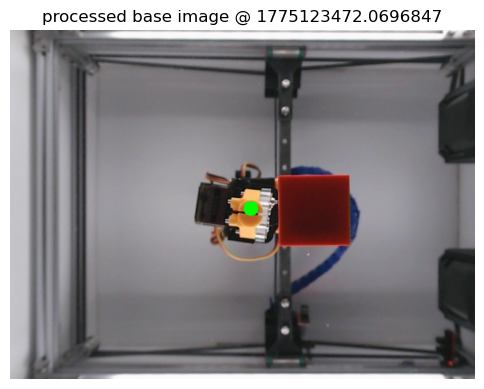

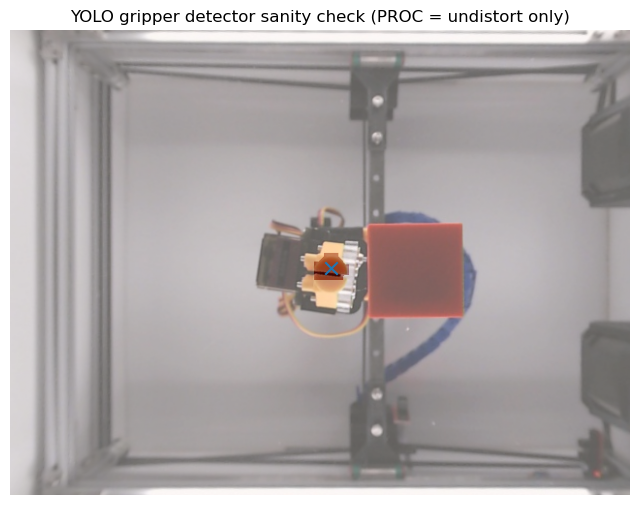

In [36]:
# 8. 현재 프레임에서 detector sanity check
img_raw, img_proc, ts = get_same_frame_raw_and_proc(robot, K, D, undistort_image)

pred = detector.predict(img_proc)
vis = img_proc.copy()

if pred.get("ok") and pred.get("center_uv") is not None:
    u, v = pred["center_uv"]
    cv2.circle(vis, (int(round(u)), int(round(v))), 10, (0, 255, 0), -1)

print(pred)
show_bgr(vis, title=f"processed base image @ {ts}")

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))

if pred.get("ok") and pred.get("mask") is not None:
    plt.imshow(pred["mask"], alpha=0.35, cmap="Reds")

if pred.get("ok") and pred.get("center_uv") is not None:
    u, v = pred["center_uv"]
    plt.scatter([u], [v], s=80, marker="x")

plt.title("YOLO gripper detector sanity check (PROC = undistort only)")
plt.axis("off")
plt.show()


## 4. Optional corner / sanity moves

In [65]:

test_points = [
    (0.99, 0.01),
    (0.99, 1.0),
    (0.00, 1.0),
    (0.00, 0.01),
]


Move to (0.99, 0.01)


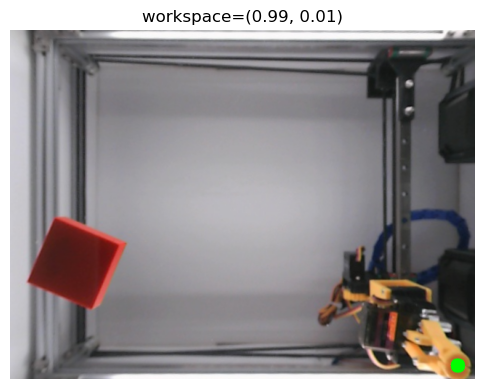

Move to (0.99, 1.00)


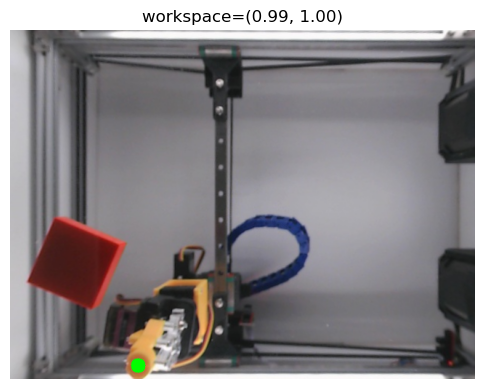

Move to (0.00, 1.00)


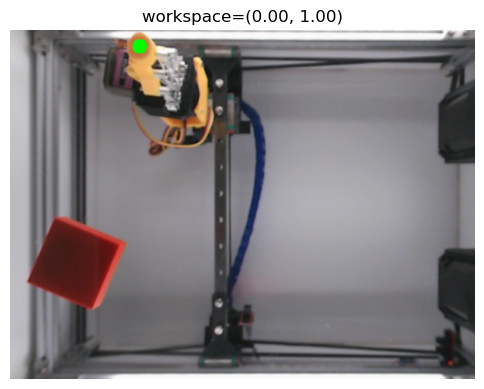

Move to (0.00, 0.01)


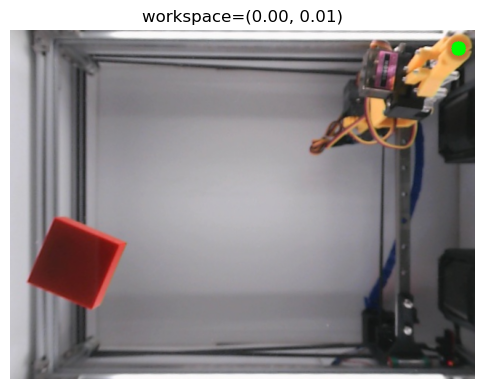

[{'x': 0.99,
  'y': 0.01,
  'pred': {'ok': True,
   'center_uv': (615.7116724738676, 461.20034843205576),
   'mask': array([[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]], shape=(480, 640), dtype=uint8),
   'contour': array([[[607, 442]],
   
          [[607, 446]],
   
          [[601, 452]],
   
          [[598, 452]],
   
          [[598, 473]],
   
          [[602, 473]],
   
          [[605, 476]],
   
          [[606, 476]],
   
          [[607, 477]],
   
          [[607, 479]],
   
          [[626, 479]],
   
          [[626, 478]],
   
          [[628, 476]],
   
          [[628, 475]],
   
          [[630, 473]],
   
          [[633, 473]],
   
          [[633, 451]],
   
          [[630, 451]],
   
          [[624, 445]],
   
          [[624, 442]]], dtype=int32),
   'score': 0.807407021522522,
   'bbox_xyxy':

In [66]:

results = []
for x, y in test_points:
    print(f"Move to ({x:.2f}, {y:.2f})")
    robot.move_xy(x, y)
    time.sleep(1.5)

    img_raw, img_proc, ts = get_same_frame_raw_and_proc(robot, K, D, undistort_image)
    pred = detector.predict(img_proc)

    results.append({"x": x, "y": y, "pred": pred, "ts": ts})
    vis = img_proc.copy()

    if pred.get("ok") and pred.get("center_uv") is not None:
        u, v = pred["center_uv"]
        cv2.circle(vis, (int(round(u)), int(round(v))), 10, (0, 255, 0), -1)

    show_bgr(vis, title=f"workspace=({x:.2f}, {y:.2f})")

results


## 5. Calibration 수집

In [19]:

# 9. Calibration 수집
ARTIFACT_PATHS = make_artifact_paths(OUTPUT_DIR)

CALIBRATION_CSV = ARTIFACT_PATHS["csv"]
FAILED_CSV = ARTIFACT_PATHS["failed_csv"]
LUT_PATH = ARTIFACT_PATHS["lut_pkl"]
SUMMARY_PATH = ARTIFACT_PATHS["summary_json"]

summary = collect_calibration(
    robot=robot,
    detector=detector,
    K=K,
    D=D,
    undistort_image_fn=undistort_image,
    config=config,
    output_dir=str(OUTPUT_DIR),
)

print("CALIBRATION_CSV:", CALIBRATION_CSV)
print("FAILED_CSV     :", FAILED_CSV)
print("LUT_PATH       :", LUT_PATH)
print("SUMMARY_PATH   :", SUMMARY_PATH)

summary


[1/1089] skip idx=0000 because it already exists in CSV
[2/1089] skip idx=0001 because it already exists in CSV
[3/1089] skip idx=0002 because it already exists in CSV
[4/1089] skip idx=0003 because it already exists in CSV
[5/1089] skip idx=0004 because it already exists in CSV
[6/1089] skip idx=0005 because it already exists in CSV
[7/1089] skip idx=0006 because it already exists in CSV
[8/1089] skip idx=0007 because it already exists in CSV
[9/1089] skip idx=0008 because it already exists in CSV
[10/1089] skip idx=0009 because it already exists in CSV
[11/1089] skip idx=0010 because it already exists in CSV
[12/1089] skip idx=0011 because it already exists in CSV
[13/1089] skip idx=0012 because it already exists in CSV
[14/1089] skip idx=0013 because it already exists in CSV
[15/1089] skip idx=0014 because it already exists in CSV
[16/1089] skip idx=0015 because it already exists in CSV
[17/1089] skip idx=0016 because it already exists in CSV
[18/1089] skip idx=0017 because it alrea

{'started_at': '2026-04-02T17:01:49.793213',
 'finished_at': '2026-04-02T17:04:45.033880',
 'output_dir': 'C:\\Users\\PC\\Desktop\\RGMC_2026\\RGMC\\RGMC\\data\\map\\robot29',
 'config': {'grid_size': 33,
  'x_min': 0.0,
  'x_max': 0.99,
  'y_min': 0.01,
  'y_max': 1.0,
  'frames_per_point': 5,
  'settle_time_sec': 0.7,
  'inter_frame_sec': 0.05,
  'reverse_xy': False,
  'resume': True,
  'save_masks': True,
  'write_debug_json': True,
  'output_subdir': 'rope_calibration',
  'custom_points': None,
  'camera_params_file': '../camera/camera-params-cr29.yaml',
  'planar_only': True,
  'prefer_raw_base_image': True,
  'min_valid_frames': 3,
  'aggregate_mode': 'median',
  'detector_lower_hsv': [10, 120, 120],
  'detector_upper_hsv': [15, 255, 255],
  'detector_kernel_size': 5,
  'detector_min_area': 100},
 'n_total_points': 1089,
 'n_success_in_this_run': 0,
 'n_fail_in_this_run': 16}

In [32]:

# 10. Calibration CSV preview
load_csv_preview(CALIBRATION_CSV, n=20)


,idx,x,y,u,v,ok,confidence,std_u,std_v,timestamp,n_valid,image_path,overlay_path,mask_path
0,0,0.000000,0.01,616.684420,25.111468,1,0.0,0.322651,0.070930,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
1,1,0.030937,0.01,617.100000,38.109399,1,0.0,0.090935,0.071768,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
2,2,0.061875,0.01,616.790438,52.587200,1,0.0,0.070202,0.047642,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
3,3,0.092812,0.01,616.736385,65.645620,1,0.0,0.084771,0.081526,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
4,4,0.123750,0.01,616.302141,79.285144,1,0.0,0.115547,0.071723,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
5,5,0.154688,0.01,616.827372,93.294349,1,0.0,0.077180,0.047198,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
6,6,0.185625,0.01,616.597978,107.017446,1,0.0,0.123656,0.036074,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
7,7,0.216562,0.01,616.652615,121.216424,1,0.0,0.065789,0.044158,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
8,8,0.247500,0.01,616.494090,134.198121,1,0.0,0.058816,0.094065,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...
9,9,0.278438,0.01,616.636648,148.777604,1,0.0,0.021041,0.040961,1.775094e+09,5,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...,C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\m...


FAILED_CSV: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\map\robot29\calibration_failed.csv
num failed rows (raw): 92
num unique failed idx (latest): 25


,idx,x,y,ok,reason,timestamp
0,377,0.556875,0.350313,0,valid_frames=2<3,1.775104e+09
1,410,0.433125,0.381250,0,valid_frames=0<3,1.775101e+09
2,476,0.433125,0.443125,0,valid_frames=0<3,1.775101e+09
3,480,0.556875,0.443125,0,valid_frames=0<3,1.775117e+09
4,483,0.649687,0.443125,0,valid_frames=0<3,1.775117e+09
5,510,0.525937,0.474062,0,valid_frames=0<3,1.775117e+09
6,875,0.525937,0.814375,0,valid_frames=0<3,1.775106e+09
7,902,0.649687,0.845313,0,valid_frames=2<3,1.775106e+09
8,905,0.556875,0.845313,0,valid_frames=1<3,1.775109e+09
9,906,0.525937,0.845313,0,valid_frames=2<3,1.775109e+09



=== idx=377 | move to (0.556875, 0.350313) | prev_reason=valid_frames=2<3 ===
  frame 00 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 01 | ok=True | center=(464.56981786643536, 271.20901994796185) | mask_exists=True | area=1153 | reason_guess=detected
  frame 02 | ok=True | center=(464.66990291262135, 271.28773168578994) | mask_exists=True | area=1133 | reason_guess=detected
  frame 03 | ok=True | center=(464.66130473637173, 270.91599642537983) | mask_exists=True | area=1119 | reason_guess=detected
  frame 04 | ok=True | center=(464.54213727193746, 271.1789748045178) | mask_exists=True | area=1151 | reason_guess=detected
  frame 05 | ok=True | center=(464.5669014084507, 270.8970070422535) | mask_exists=True | area=1136 | reason_guess=detected
  frame 06 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 07 | ok=False | center=(None, None) | 

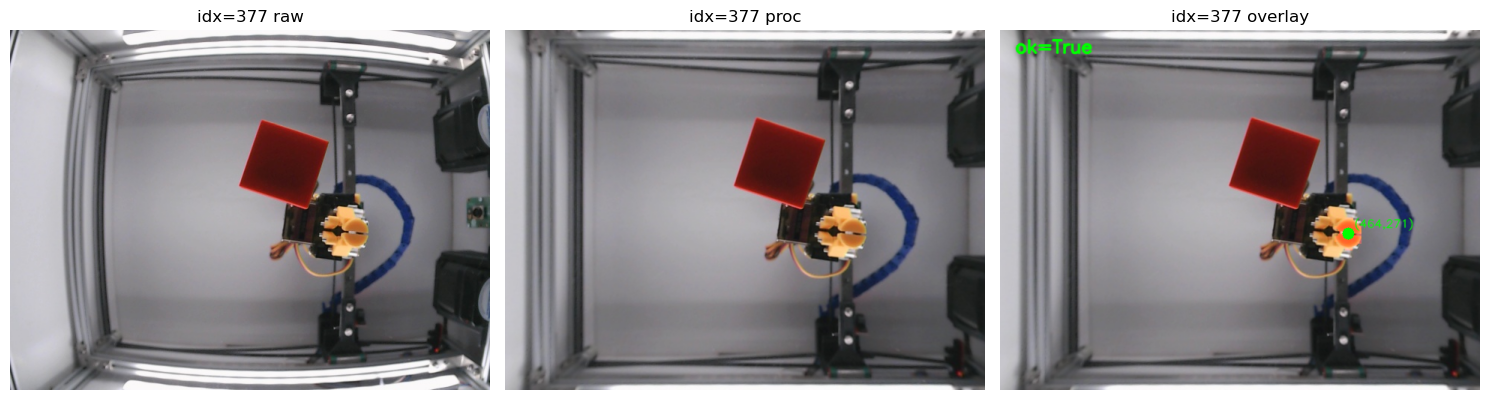


=== idx=410 | move to (0.433125, 0.381250) | prev_reason=valid_frames=0<3 ===
  frame 00 | ok=True | center=(450.55442176870747, 216.92431972789115) | mask_exists=True | area=1176 | reason_guess=detected
  frame 01 | ok=True | center=(450.62320067739205, 216.9644369178662) | mask_exists=True | area=1181 | reason_guess=detected
  frame 02 | ok=True | center=(450.5072463768116, 218.12047101449275) | mask_exists=True | area=1104 | reason_guess=detected
  frame 03 | ok=True | center=(450.5210792580101, 216.96795952782463) | mask_exists=True | area=1186 | reason_guess=detected
  frame 04 | ok=True | center=(450.3887399463807, 218.1823056300268) | mask_exists=True | area=1119 | reason_guess=detected
  frame 05 | ok=True | center=(450.54297872340425, 216.93446808510637) | mask_exists=True | area=1175 | reason_guess=detected
  frame 06 | ok=True | center=(450.43036912751677, 216.93791946308724) | mask_exists=True | area=1192 | reason_guess=detected
  frame 07 | ok=True | center=(450.533333333

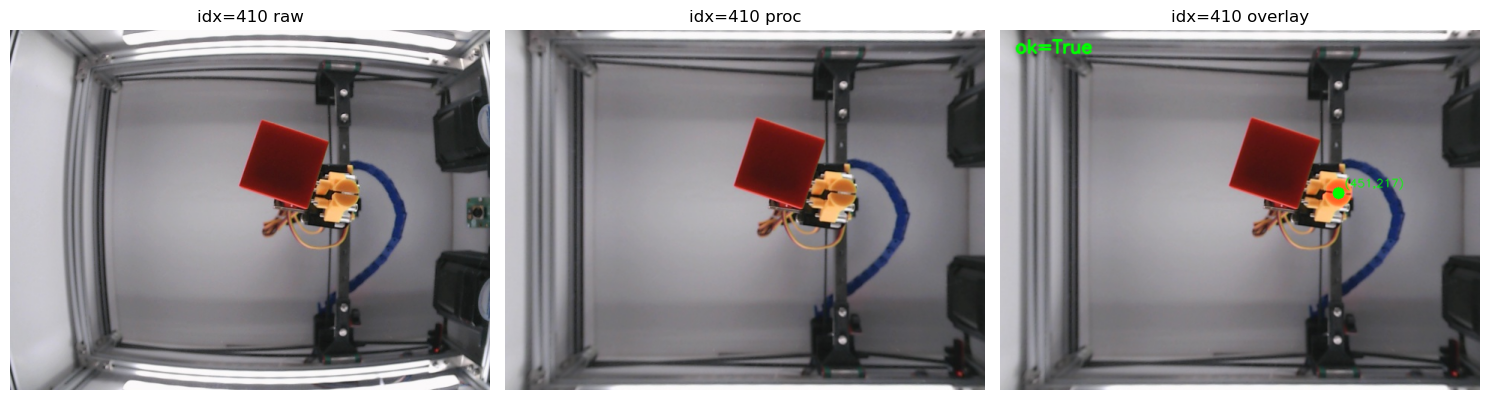


=== idx=476 | move to (0.433125, 0.443125) | prev_reason=valid_frames=0<3 ===
  frame 00 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 01 | ok=True | center=(422.1343396226415, 215.59471698113208) | mask_exists=True | area=1325 | reason_guess=detected
  frame 02 | ok=True | center=(422.10877719429857, 215.51837959489873) | mask_exists=True | area=1333 | reason_guess=detected
  frame 03 | ok=True | center=(422.29871114480665, 215.41546626231994) | mask_exists=True | area=1319 | reason_guess=detected
  frame 04 | ok=True | center=(422.20617005267115, 215.54251316779533) | mask_exists=True | area=1329 | reason_guess=detected
  frame 05 | ok=True | center=(422.0775018811136, 215.54928517682467) | mask_exists=True | area=1329 | reason_guess=detected
  frame 06 | ok=True | center=(422.19065561416727, 215.49660889223813) | mask_exists=True | area=1327 | reason_guess=detected
  frame 07 | ok=True | center=(422.09063444

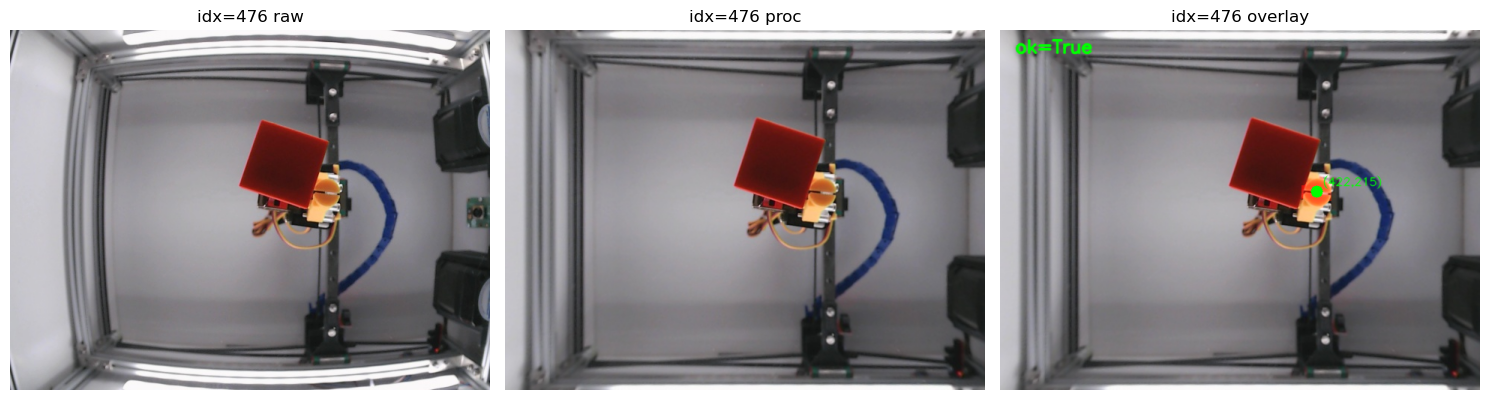


=== idx=480 | move to (0.556875, 0.443125) | prev_reason=valid_frames=0<3 ===
  frame 00 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 01 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 02 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 03 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 04 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 05 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 06 | ok=False | center=(None, None) | mask_exists=False | area=None | reason_guess=mask_missing_or_detection_failed
  frame 07 | ok=False | center=(None, None) | mask_ex

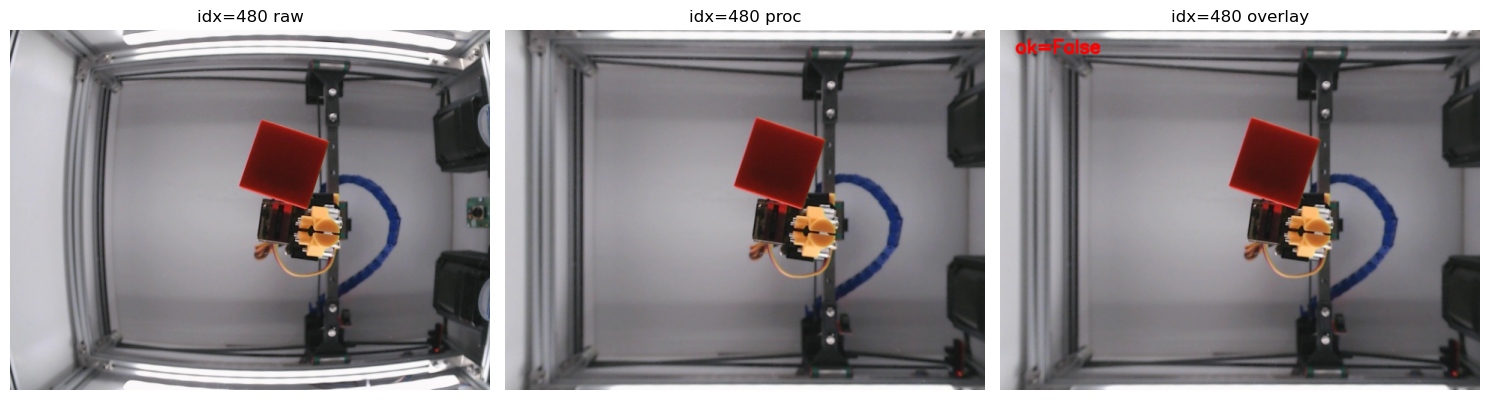


=== idx=483 | move to (0.649687, 0.443125) | prev_reason=valid_frames=0<3 ===


KeyboardInterrupt: 

In [33]:
# 실패 포인트만 재방문해서 raw / proc / overlay / json / summary 저장하는 단일 디버그 셀

import json
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------
# 설정
# -----------------------------
SETTLE_TIME_SEC = 1.0        # move 후 안정화 대기
N_FRAMES_PER_POINT = 10      # 각 실패점에서 몇 프레임 볼지
FRAME_INTERVAL_SEC = 0.15    # 프레임 간 대기
SHOW_PREVIEW = True          # 각 점마다 마지막 overlay를 notebook에 표시할지
TARGET_IDXS = None           # 예: [643, 874, 973], 전체 실패점이면 None

DEBUG_DIR = Path(OUTPUT_DIR) / "debug_failed_points"
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# failed csv 읽기
# -----------------------------
failed_df = pd.read_csv(FAILED_CSV)

if failed_df.empty:
    raise RuntimeError(f"FAILED_CSV is empty: {FAILED_CSV}")

# 같은 idx가 여러 번 실패했을 수 있으므로 마지막 기록만 사용
latest_failed = (
    failed_df
    .drop_duplicates(subset=["idx"], keep="last")
    .sort_values("idx")
    .reset_index(drop=True)
)

if TARGET_IDXS is not None:
    latest_failed = latest_failed[latest_failed["idx"].isin(TARGET_IDXS)].reset_index(drop=True)

print("FAILED_CSV:", FAILED_CSV)
print("num failed rows (raw):", len(failed_df))
print("num unique failed idx (latest):", len(latest_failed))
display(latest_failed)

# -----------------------------
# detector 결과를 사람이 보기 쉽게 정리
# -----------------------------
def summarize_pred(pred):
    out = {
        "ok": False,
        "center_uv": None,
        "mask_exists": False,
        "mask_shape": None,
        "mask_area_px": None,
        "reason_guess": None,
        "raw_keys": None,
    }

    if pred is None:
        out["reason_guess"] = "pred_is_none"
        return out

    if not isinstance(pred, dict):
        out["reason_guess"] = f"pred_not_dict: {type(pred)}"
        return out

    out["raw_keys"] = list(pred.keys())
    out["ok"] = bool(pred.get("ok", False))

    center_uv = pred.get("center_uv", None)
    if center_uv is not None:
        try:
            out["center_uv"] = [float(center_uv[0]), float(center_uv[1])]
        except Exception:
            out["center_uv"] = str(center_uv)

    mask = pred.get("mask", None)
    if mask is not None:
        out["mask_exists"] = True
        try:
            mask_np = np.asarray(mask)
            out["mask_shape"] = list(mask_np.shape)
            if mask_np.ndim >= 2:
                out["mask_area_px"] = int((mask_np > 0).sum())
        except Exception as e:
            out["mask_shape"] = f"mask_parse_error: {e}"

    if not out["ok"]:
        if not out["mask_exists"]:
            out["reason_guess"] = "mask_missing_or_detection_failed"
        elif out["center_uv"] is None:
            out["reason_guess"] = "center_missing"
        else:
            out["reason_guess"] = "pred_ok_false_but_mask_center_exist"
    else:
        out["reason_guess"] = "detected"

    return out

# -----------------------------
# overlay 생성
# -----------------------------
def make_overlay(img_proc, pred):
    vis = img_proc.copy()

    if isinstance(pred, dict):
        mask = pred.get("mask", None)
        center_uv = pred.get("center_uv", None)
        ok = bool(pred.get("ok", False))

        # mask overlay
        if mask is not None:
            try:
                mask_np = np.asarray(mask)
                if mask_np.ndim == 2:
                    colored = np.zeros_like(vis)
                    colored[..., 2] = (mask_np > 0).astype(np.uint8) * 255  # red overlay
                    vis = cv2.addWeighted(vis, 1.0, colored, 0.35, 0)
            except Exception:
                pass

        # center
        if center_uv is not None:
            try:
                u, v = int(round(center_uv[0])), int(round(center_uv[1]))
                color = (0, 255, 0) if ok else (0, 165, 255)
                cv2.circle(vis, (u, v), 8, color, -1)
                cv2.putText(
                    vis,
                    f"({u},{v})",
                    (u + 8, v - 8),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    1,
                    cv2.LINE_AA,
                )
            except Exception:
                pass

        # status text
        status_text = f"ok={pred.get('ok', None)}"
        cv2.putText(
            vis,
            status_text,
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0) if ok else (0, 0, 255),
            2,
            cv2.LINE_AA,
        )

    return vis

# -----------------------------
# 디버그 실행
# -----------------------------
all_rows = []

for _, row in latest_failed.iterrows():
    idx = int(row["idx"])
    x = float(row["x"])
    y = float(row["y"])
    fail_reason_prev = row.get("reason", None)

    point_dir = DEBUG_DIR / f"idx_{idx:04d}_x_{x:.6f}_y_{y:.6f}"
    point_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== idx={idx} | move to ({x:.6f}, {y:.6f}) | prev_reason={fail_reason_prev} ===")

    # move
    robot.move_xy(x, y)
    time.sleep(SETTLE_TIME_SEC)

    point_rows = []

    for frame_i in range(N_FRAMES_PER_POINT):
        rec = {
            "idx": idx,
            "x": x,
            "y": y,
            "frame": frame_i,
            "prev_failed_reason": fail_reason_prev,
            "det_ok": None,
            "center_u": None,
            "center_v": None,
            "mask_exists": None,
            "mask_area_px": None,
            "reason_guess": None,
            "img_ts": None,
            "error": None,
        }

        try:
            # 노트북 helper 사용: 같은 raw에서 proc 생성
            img_raw, img_proc, ts_img = get_same_frame_raw_and_proc(robot, K, D, undistort_image)
            pred = detector.predict(img_proc)

            pred_summary = summarize_pred(pred)
            vis = make_overlay(img_proc, pred)

            rec["img_ts"] = ts_img
            rec["det_ok"] = pred_summary["ok"]
            rec["mask_exists"] = pred_summary["mask_exists"]
            rec["mask_area_px"] = pred_summary["mask_area_px"]
            rec["reason_guess"] = pred_summary["reason_guess"]

            if pred_summary["center_uv"] is not None and isinstance(pred_summary["center_uv"], list):
                rec["center_u"] = pred_summary["center_uv"][0]
                rec["center_v"] = pred_summary["center_uv"][1]

            # 파일 저장
            raw_path = point_dir / f"frame_{frame_i:02d}_raw.png"
            proc_path = point_dir / f"frame_{frame_i:02d}_proc.png"
            overlay_path = point_dir / f"frame_{frame_i:02d}_overlay.png"
            json_path = point_dir / f"frame_{frame_i:02d}_pred.json"

            cv2.imwrite(str(raw_path), img_raw)
            cv2.imwrite(str(proc_path), img_proc)
            cv2.imwrite(str(overlay_path), vis)

            with open(json_path, "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "idx": idx,
                        "x": x,
                        "y": y,
                        "frame": frame_i,
                        "prev_failed_reason": fail_reason_prev,
                        "pred_summary": pred_summary,
                        "pred_raw": str(pred),
                    },
                    f,
                    ensure_ascii=False,
                    indent=2,
                )

            print(
                f"  frame {frame_i:02d} | ok={rec['det_ok']} | "
                f"center=({rec['center_u']}, {rec['center_v']}) | "
                f"mask_exists={rec['mask_exists']} | area={rec['mask_area_px']} | "
                f"reason_guess={rec['reason_guess']}"
            )

            last_vis = vis.copy()
            last_raw = img_raw.copy()
            last_proc = img_proc.copy()

        except Exception as e:
            rec["error"] = repr(e)
            print(f"  frame {frame_i:02d} | exception: {e}")

        point_rows.append(rec)
        all_rows.append(rec)
        time.sleep(FRAME_INTERVAL_SEC)

    # 점별 요약 저장
    point_df = pd.DataFrame(point_rows)
    point_summary = {
        "idx": idx,
        "x": x,
        "y": y,
        "prev_failed_reason": fail_reason_prev,
        "n_frames": int(len(point_df)),
        "n_ok_true": int((point_df["det_ok"] == True).sum()) if "det_ok" in point_df.columns else 0,
        "n_ok_false": int((point_df["det_ok"] == False).sum()) if "det_ok" in point_df.columns else 0,
        "n_mask_exists": int((point_df["mask_exists"] == True).sum()) if "mask_exists" in point_df.columns else 0,
        "n_center_exists": int(point_df["center_u"].notna().sum()) if "center_u" in point_df.columns else 0,
        "reason_guess_counts": point_df["reason_guess"].value_counts(dropna=False).to_dict() if "reason_guess" in point_df.columns else {},
        "error_count": int(point_df["error"].notna().sum()) if "error" in point_df.columns else 0,
    }

    with open(point_dir / "point_summary.json", "w", encoding="utf-8") as f:
        json.dump(point_summary, f, ensure_ascii=False, indent=2)

    if SHOW_PREVIEW and "last_vis" in locals():
        fig = plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(last_raw, cv2.COLOR_BGR2RGB))
        plt.title(f"idx={idx} raw")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(last_proc, cv2.COLOR_BGR2RGB))
        plt.title(f"idx={idx} proc")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(last_vis, cv2.COLOR_BGR2RGB))
        plt.title(f"idx={idx} overlay")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# -----------------------------
# 전체 요약 저장
# -----------------------------
debug_df = pd.DataFrame(all_rows)
debug_csv = DEBUG_DIR / "debug_summary.csv"
debug_df.to_csv(debug_csv, index=False)

print("\nSaved debug summary:", debug_csv)

if not debug_df.empty:
    per_idx_summary = (
        debug_df.groupby(["idx", "x", "y"])
        .agg(
            n_frames=("frame", "count"),
            n_ok_true=("det_ok", lambda s: int((s == True).sum())),
            n_ok_false=("det_ok", lambda s: int((s == False).sum())),
            n_mask_exists=("mask_exists", lambda s: int((s == True).sum())),
            n_center_exists=("center_u", lambda s: int(s.notna().sum())),
            n_errors=("error", lambda s: int(s.notna().sum())),
        )
        .reset_index()
        .sort_values("idx")
    )

    print("\n[per-idx summary]")
    display(per_idx_summary)

    print("\n[reason_guess counts]")
    display(
        debug_df.groupby(["idx", "reason_guess"])
        .size()
        .reset_index(name="count")
        .sort_values(["idx", "count"], ascending=[True, False])
    )

In [ ]:

# 11. 실패 포인트 preview
list_failed_points(FAILED_CSV)


## 6. LUT 생성

In [34]:

# 12. LUT 생성
dataset = parse_dataset(str(CALIBRATION_CSV), min_confidence=0.0, require_ok=True)
lut = build_bidirectional_lookup(dataset, method="clough_tocher")
meta_path = save_lookup_table(lut, str(LUT_PATH))

print("CALIBRATION_CSV:", CALIBRATION_CSV)
print("LUT_PATH       :", LUT_PATH)
print("meta_path      :", meta_path)
print("metadata       :", lut.metadata)


CALIBRATION_CSV: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\map\robot29\calibration.csv
LUT_PATH       : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\map\robot29\lut.pkl
meta_path      : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\map\robot29\lut_metadata.json
metadata       : {'method': 'clough_tocher', 'num_points': 1073, 'workspace_bounds': {'x_min': 0.0, 'x_max': 0.99, 'y_min': 0.01, 'y_max': 1.0}, 'pixel_bounds': {'u_min': 175.02382908792111, 'u_max': 617.1, 'v_min': 21.997542997542997, 'v_max': 461.1322241681261}}


CALIBRATION_CSV: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\map\robot29\calibration.csv
{'grid_size': 33, 'valid_projected_points': 1089, 'invalid_projected_points': 0, 'workspace_bounds': {'x_min': 0.0, 'x_max': 0.99, 'y_min': 0.01, 'y_max': 1.0}}


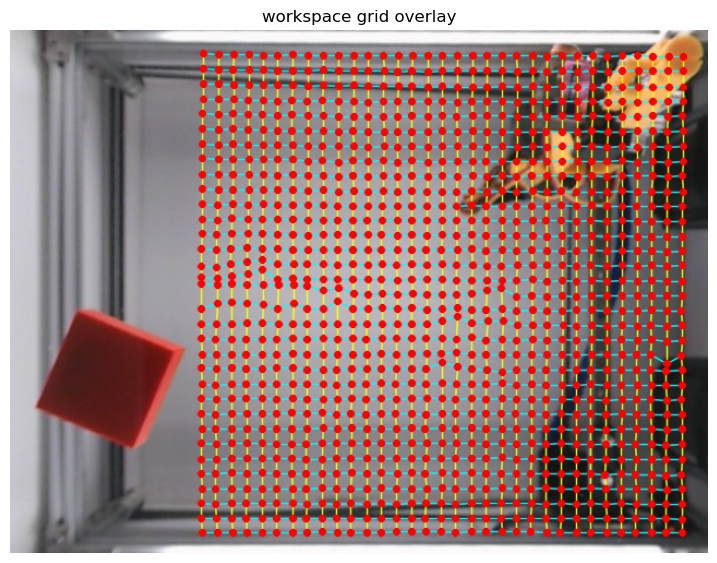

In [35]:

# 13. Overlay 시각화
df = pd.read_csv(CALIBRATION_CSV)
image_path = df.iloc[0]["image_path"]
image = cv2.imread(str(image_path))
lut_loaded = load_lut(str(LUT_PATH))

overlay, info = draw_grid_overlay(
    image,
    lut_loaded,
    grid_size=config.grid_size,
    x_min=config.x_min,
    x_max=config.x_max,
    y_min=config.y_min,
    y_max=config.y_max,
    draw_labels=False,
)

print("CALIBRATION_CSV:", CALIBRATION_CSV)
print(info)
show_bgr(overlay, title="workspace grid overlay", figsize=(9, 9))


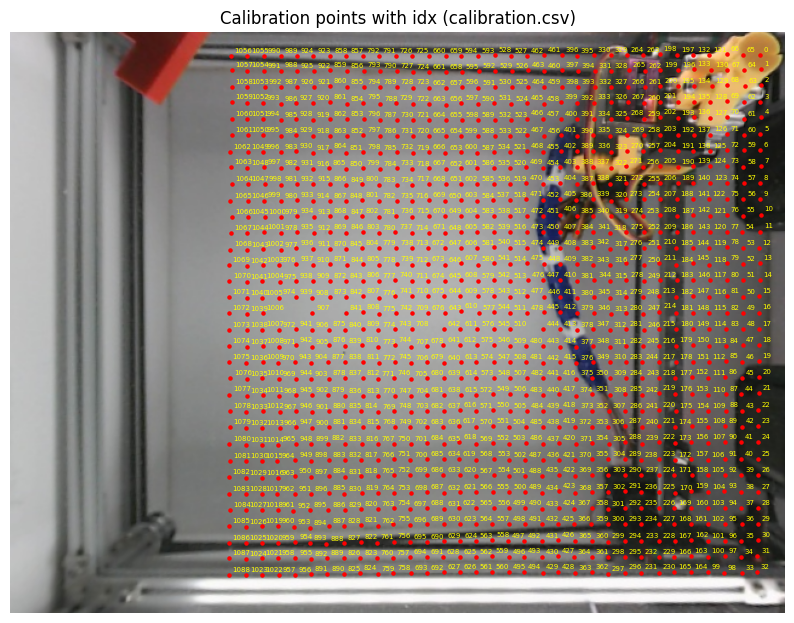

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

df = pd.read_csv(CALIBRATION_CSV)
image_path = df.iloc[0]["image_path"]

img = cv2.imread(str(image_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(img)

for _, row in df.iterrows():
    u = row["u"]
    v = row["v"]
    idx = int(row["idx"])
    plt.text(u + 3, v - 3, str(idx), fontsize=5, color="yellow")
    plt.scatter([u], [v], s=5, c="red")

plt.title(f"Calibration points with idx ({CALIBRATION_CSV.name})")
plt.axis("off")
plt.show()

## 7. LUT 사용 예시

In [19]:

# 14. PixelToWorkspaceMapper 로 runtime 변환 예시
mapper = PixelToWorkspaceMapper(
    str(LUT_PATH),
    clamp_to_workspace=False,
    x_min=config.x_min,
    x_max=config.x_max,
    y_min=config.y_min,
    y_max=config.y_max,
)

sample_uv = [(300.0, 250.0), (320.0, 260.0)]
xy_points = mapper.convert_many(sample_uv)

print("sample_uv :", sample_uv)
print("xy_points :", xy_points)


sample_uv : [(300.0, 250.0), (320.0, 260.0)]
xy_points : [(0.5553687048724896, 0.7330150718433379), (0.5790040810029791, 0.6876840301911772)]


In [20]:

# 15. LUT consistency check
csv_path = Path(LUT_PATH).parent / "calibration.csv"
df = pd.read_csv(csv_path)

errors = []
failed = []

for i, row in df.iterrows():
    u = row["u"]
    v = row["v"]
    x_gt = row["x"]
    y_gt = row["y"]

    try:
        x_lut, y_lut = mapper.convert_one(u, v)
        err = np.sqrt((x_lut - x_gt)**2 + (y_lut - y_gt)**2)
        errors.append(err)
    except Exception as e:
        failed.append((i, str(e)))

errors = np.array(errors)

print("===== LUT consistency check =====")
print("csv_path :", csv_path)
print("count    :", len(errors))
print("failed   :", len(failed))
if len(errors) > 0:
    print("mean err :", errors.mean())
    print("median   :", np.median(errors))
    print("max err  :", errors.max())

if len(failed) > 0:
    print("\nFirst 5 failures:")
    for item in failed[:5]:
        print(item)


===== LUT consistency check =====
csv_path : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data\map\robot29\calibration.csv
count    : 1084
failed   : 0
mean err : 8.765010238265778e-17
median   : 2.7755575615628914e-17
max err  : 8.95090418262362e-16


## 8. Optional diagnostic cells

timestamp: 1775045427.068462

[raw info]
type: <class 'numpy.ndarray'>
shape: (480, 640, 3) dtype: uint8 min/max: 0 255

[proc info]
type: <class 'numpy.ndarray'>
shape: (480, 640, 3) dtype: uint8 min/max: 0 255

[pred_raw]
{'ok': False, 'center_uv': None, 'mask': None, 'contour': None, 'score': None, 'bbox_xyxy': None}

[pred_proc]
{'ok': False, 'center_uv': None, 'mask': None, 'contour': None, 'score': None, 'bbox_xyxy': None}


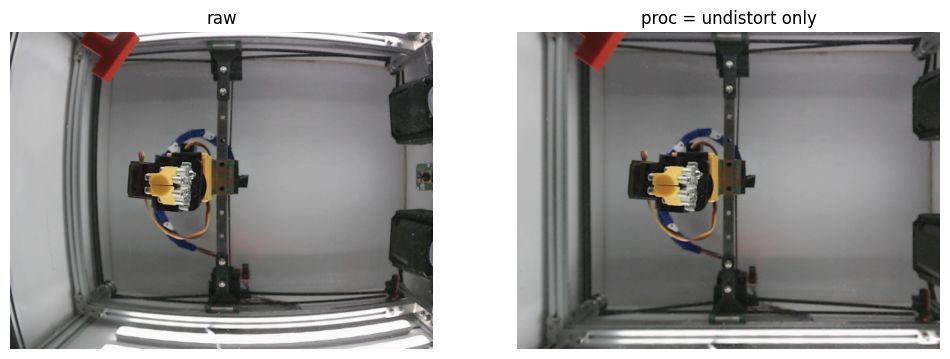

In [36]:

# 16. Raw vs proc 비교
img_raw, img_proc, ts = get_same_frame_raw_and_proc(robot, K, D, undistort_image)

print("timestamp:", ts)

print("\n[raw info]")
print("type:", type(img_raw))
if isinstance(img_raw, np.ndarray):
    print("shape:", img_raw.shape, "dtype:", img_raw.dtype, "min/max:", img_raw.min(), img_raw.max())

print("\n[proc info]")
print("type:", type(img_proc))
if isinstance(img_proc, np.ndarray):
    print("shape:", img_proc.shape, "dtype:", img_proc.dtype, "min/max:", img_proc.min(), img_proc.max())

pred_raw = detector.predict(img_raw)
pred_proc = detector.predict(img_proc)

print("\n[pred_raw]")
print(pred_raw)

print("\n[pred_proc]")
print(pred_proc)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
plt.title("raw")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
plt.title("proc = undistort only")
plt.axis("off")

plt.show()


ts_img: 1775045446.7894802

[pred]
{'ok': False, 'center_uv': None, 'mask': None, 'contour': None, 'score': None, 'bbox_xyxy': None}

[state]
state: {'x_norm': 0.5235714285714286, 'y_norm': 0.9162142857142858, 'z_norm': 0.09999999999999998, 'rotation': 0, 'claw_norm': 0.0, 'z_current': '0.02', 'rotation_current': '0.03', 'claw_current': '0.00'}
ts_state: 1775045448.3066552
dt_state_minus_img: 1.5171749591827393
x_state = 0.523571, y_state = 0.916214


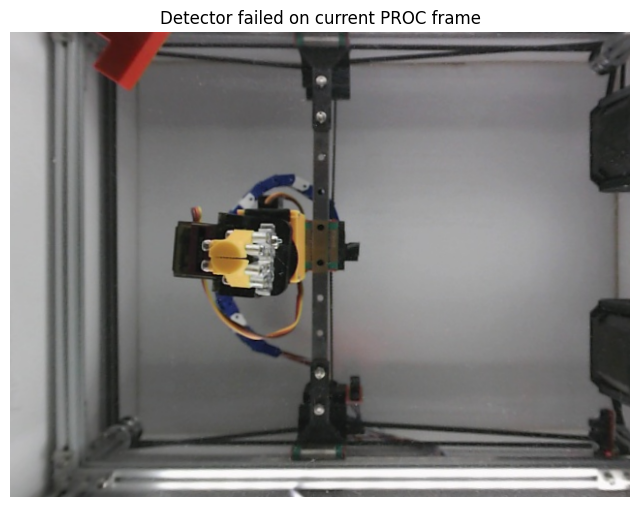

RuntimeError: Detector failed on current frame.

In [37]:

# 17. 현재 프레임에서 detector uv -> LUT xy 와 robot state 비교
img_raw, img_proc, ts_img = get_same_frame_raw_and_proc(robot, K, D, undistort_image)
pred = detector.predict(img_proc)

x_state, y_state, ts_state, state = get_state_xy(robot)

print("ts_img:", ts_img)
print("\n[pred]")
print(pred)

print("\n[state]")
print("state:", state)
print("ts_state:", ts_state)

if ts_img is not None and ts_state is not None:
    print("dt_state_minus_img:", ts_state - ts_img)

print(f"x_state = {x_state:.6f}, y_state = {y_state:.6f}")

if not pred.get("ok"):
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
    plt.title("Detector failed on current PROC frame")
    plt.axis("off")
    plt.show()
    raise RuntimeError("Detector failed on current frame.")

u, v = pred["center_uv"]
x_lut, y_lut = mapper.convert_one(u, v)

dx = x_lut - x_state
dy = y_lut - y_state
err = float(np.sqrt(dx * dx + dy * dy))

print(f"u, v         = ({u:.3f}, {v:.3f})")
print(f"x_lut, y_lut = ({x_lut:.6f}, {y_lut:.6f})")
print(f"dx, dy       = ({dx:.6f}, {dy:.6f})")
print(f"err          = {err:.6f}")


Generated off-grid test points:
(0.1033, 0.1)
(0.1043, 0.3024)
(0.1, 0.5057)
(0.1031, 0.7034)
(0.1, 0.8994)
(0.2984, 0.1051)
(0.3017, 0.3039)
(0.2993, 0.4967)
(0.3007, 0.6948)
(0.3039, 0.9)
(0.5031, 0.1)
(0.5056, 0.3047)
(0.5033, 0.4963)
(0.4959, 0.7022)
(0.4956, 0.8997)
(0.6967, 0.102)
(0.6992, 0.304)
(0.704, 0.5037)
(0.6986, 0.6975)
(0.7022, 0.8957)
(0.8964, 0.1)
(0.9, 0.302)
(0.9, 0.5034)
(0.8995, 0.7008)
(0.8957, 0.8954)
[1/25] move to (0.1033, 0.1000)
  ok | uv=(576.12, 70.64) | lut=(0.1514, 0.1156) | dx=0.048131, dy=0.015594, err=0.050594
[2/25] move to (0.1043, 0.3024)
  ok | uv=(487.24, 70.91) | lut=(0.1500, 0.3136) | dx=0.045732, dy=0.011228, err=0.047090
[3/25] move to (0.1000, 0.5057)
  ok | uv=(395.90, 68.00) | lut=(0.1418, 0.5183) | dx=0.041835, dy=0.012634, err=0.043701
[4/25] move to (0.1031, 0.7034)
  ok | uv=(308.88, 69.97) | lut=(0.1459, 0.7161) | dx=0.042787, dy=0.012664, err=0.044622
[5/25] move to (0.1000, 0.8994)
  ok | uv=(222.54, 67.29) | lut=(0.1400, 0.9090) | 

,x_cmd,y_cmd,x_state,y_state,ts_img,ts_state,dt_state_minus_img,ok,u,v,x_lut,y_lut,dx,dy,err
0,0.1033,0.1000,0.103500,0.099714,1.775091e+09,1.775091e+09,1.629300,True,576.119159,70.641745,0.151431,0.115594,0.048131,0.015594,0.050594
1,0.1043,0.3024,0.104357,0.302071,1.775091e+09,1.775091e+09,1.632524,True,487.235659,70.912403,0.150032,0.313628,0.045732,0.011228,0.047090
2,0.1000,0.5057,0.100000,0.505357,1.775091e+09,1.775091e+09,1.818244,True,395.901626,68.000000,0.141835,0.518334,0.041835,0.012634,0.043701
3,0.1031,0.7034,0.103214,0.702857,1.775091e+09,1.775091e+09,1.832774,True,308.882353,69.966387,0.145887,0.716064,0.042787,0.012664,0.044622
4,0.1000,0.8994,0.100071,0.898929,1.775091e+09,1.775091e+09,1.771353,True,222.542265,67.293461,0.140007,0.908982,0.040007,0.009582,0.041139
5,0.2984,0.1051,0.298500,0.105071,1.775091e+09,1.775091e+09,1.629041,True,572.661836,157.189211,0.346176,0.122253,0.047776,0.017153,0.050762
6,0.3017,0.3039,0.301786,0.303500,1.775091e+09,1.775091e+09,1.741717,True,484.589271,157.820620,0.347089,0.318975,0.045389,0.015075,0.047827
7,0.2993,0.4967,0.299286,0.496214,1.775091e+09,1.775091e+09,1.836712,True,399.775806,157.230645,0.346423,0.508775,0.047123,0.012075,0.048646
8,0.3007,0.6948,0.300786,0.694571,1.775091e+09,1.775091e+09,1.828706,True,311.659690,157.542636,0.345797,0.707723,0.045097,0.012923,0.046912
9,0.3039,0.9000,0.304000,0.899500,1.775091e+09,1.775091e+09,1.641978,True,222.108424,157.806505,0.345570,0.910639,0.041670,0.010639,0.043006



===== Off-grid error summary =====
num valid         : 25 / 25
mean err (norm)   : 0.045163
median err (norm) : 0.046367
max err (norm)    : 0.050762
mean err (mm)     : 6.774
median err (mm)   : 6.955
max err (mm)      : 7.614
mean dt_state-img : 1.713 sec
max dt_state-img  : 1.947 sec

Saved: offgrid_error_results.csv


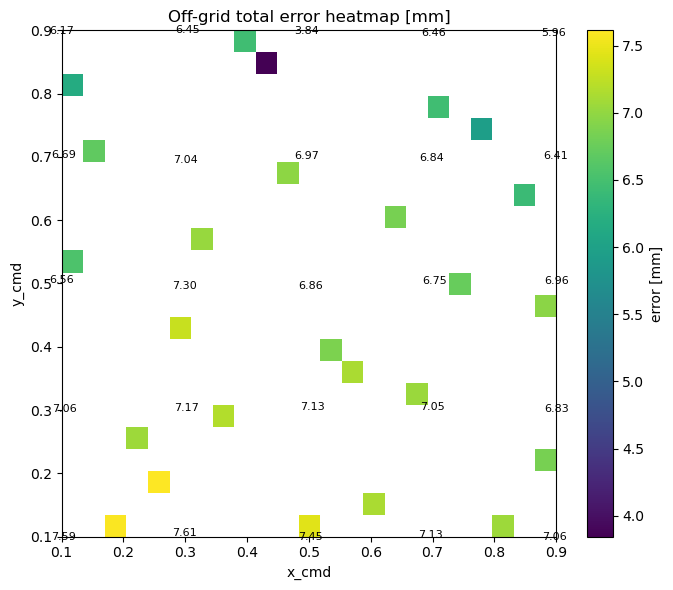

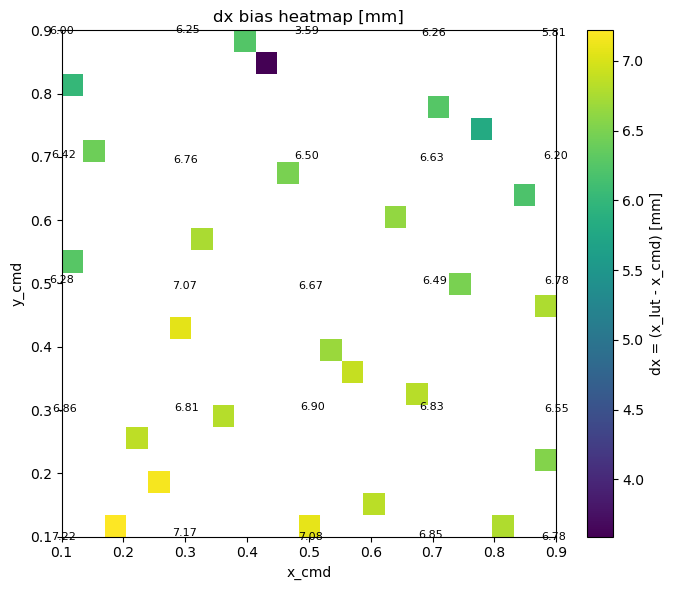

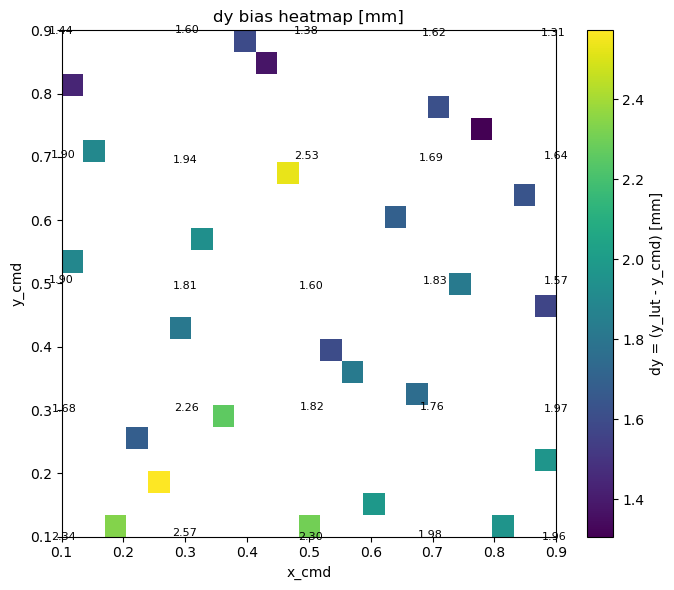

In [21]:
# ============================================
# Off-grid error test + heatmap (single cell)
# Uses notebook variables already defined:
#   robot, detector, mapper, K, D, undistort_image, get_same_frame_raw_and_proc, get_state_xy
# ============================================

import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORKSPACE_MM = 150.0
GRID_SIZE = 33

def is_near_grid_value(val: float, grid_size: int = GRID_SIZE, tol: float = 0.003) -> bool:
    spacing = 1.0 / (grid_size - 1)
    nearest = round(val / spacing) * spacing
    return abs(val - nearest) < tol

def generate_offgrid_points(
    n_x: int = 5,
    n_y: int = 5,
    x_min: float = 0.10,
    x_max: float = 0.90,
    y_min: float = 0.10,
    y_max: float = 0.90,
    grid_size: int = GRID_SIZE,
    tol_to_grid: float = 0.003,
    jitter: float = 0.006,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    xs = np.linspace(x_min, x_max, n_x)
    ys = np.linspace(y_min, y_max, n_y)
    pts = []

    for x0 in xs:
        for y0 in ys:
            x = float(np.clip(x0 + rng.uniform(-jitter, jitter), x_min, x_max))
            y = float(np.clip(y0 + rng.uniform(-jitter, jitter), y_min, y_max))

            for _ in range(100):
                if (not is_near_grid_value(x, grid_size, tol_to_grid)) and \
                   (not is_near_grid_value(y, grid_size, tol_to_grid)):
                    break
                x = float(np.clip(x0 + rng.uniform(-jitter, jitter), x_min, x_max))
                y = float(np.clip(y0 + rng.uniform(-jitter, jitter), y_min, y_max))

            pts.append((round(x, 4), round(y, 4)))

    return pts

TEST_POINTS = generate_offgrid_points(
    n_x=5,
    n_y=5,
    x_min=0.10,
    x_max=0.90,
    y_min=0.10,
    y_max=0.90,
    grid_size=GRID_SIZE,
    tol_to_grid=0.003,
    jitter=0.006,
    seed=42,
)

print("Generated off-grid test points:")
for p in TEST_POINTS:
    print(p)

rows = []

for i, (x_cmd, y_cmd) in enumerate(TEST_POINTS, start=1):
    print(f"[{i}/{len(TEST_POINTS)}] move to ({x_cmd:.4f}, {y_cmd:.4f})")

    # move
    robot.move_xy(x_cmd, y_cmd)

    # settle
    time.sleep(1.5)

    try:
        # image + preprocess
        img_raw, img_proc, ts_img = get_same_frame_raw_and_proc(robot, K, D, undistort_image)

        # detect
        pred = detector.predict(img_proc)
        u, v = pred["center_uv"]

        # state
        x_state, y_state, ts_state, state = get_state_xy(robot)

        # LUT
        x_lut, y_lut = mapper.convert_one(u, v)

        # command-based error
        dx = x_lut - x_cmd
        dy = y_lut - y_cmd
        err = math.sqrt(dx * dx + dy * dy)

        rows.append({
            "x_cmd": x_cmd,
            "y_cmd": y_cmd,
            "x_state": x_state,
            "y_state": y_state,
            "ts_img": ts_img,
            "ts_state": ts_state,
            "dt_state_minus_img": ts_state - ts_img,
            "ok": True,
            "u": u,
            "v": v,
            "x_lut": x_lut,
            "y_lut": y_lut,
            "dx": dx,
            "dy": dy,
            "err": err,
        })

        print(
            f"  ok | uv=({u:.2f}, {v:.2f}) "
            f"| lut=({x_lut:.4f}, {y_lut:.4f}) "
            f"| dx={dx:.6f}, dy={dy:.6f}, err={err:.6f}"
        )

    except Exception as e:
        rows.append({
            "x_cmd": x_cmd,
            "y_cmd": y_cmd,
            "x_state": np.nan,
            "y_state": np.nan,
            "ts_img": np.nan,
            "ts_state": np.nan,
            "dt_state_minus_img": np.nan,
            "ok": False,
            "u": np.nan,
            "v": np.nan,
            "x_lut": np.nan,
            "y_lut": np.nan,
            "dx": np.nan,
            "dy": np.nan,
            "err": np.nan,
            "errmsg": str(e),
        })
        print(f"  failed | {e}")

df_offgrid = pd.DataFrame(rows)
display(df_offgrid)

df_ok = df_offgrid[df_offgrid["ok"]].copy()

print("\n===== Off-grid error summary =====")
if len(df_ok) > 0:
    err_norm = df_ok["err"].to_numpy()
    err_mm = err_norm * WORKSPACE_MM

    print(f"num valid         : {len(df_ok)} / {len(df_offgrid)}")
    print(f"mean err (norm)   : {np.mean(err_norm):.6f}")
    print(f"median err (norm) : {np.median(err_norm):.6f}")
    print(f"max err (norm)    : {np.max(err_norm):.6f}")
    print(f"mean err (mm)     : {np.mean(err_mm):.3f}")
    print(f"median err (mm)   : {np.median(err_mm):.3f}")
    print(f"max err (mm)      : {np.max(err_mm):.3f}")

    dt = df_ok["dt_state_minus_img"].to_numpy()
    print(f"mean dt_state-img : {np.mean(dt):.3f} sec")
    print(f"max dt_state-img  : {np.max(dt):.3f} sec")
else:
    print("No valid rows.")

# Save CSV
csv_path = "offgrid_error_results.csv"
df_offgrid.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

# -----------------------------
# Heatmaps
# -----------------------------
if len(df_ok) > 0:
    err_grid = df_ok.pivot(index="y_cmd", columns="x_cmd", values="err").sort_index().sort_index(axis=1)
    dx_grid = df_ok.pivot(index="y_cmd", columns="x_cmd", values="dx").sort_index().sort_index(axis=1)
    dy_grid = df_ok.pivot(index="y_cmd", columns="x_cmd", values="dy").sort_index().sort_index(axis=1)

    err_mm = err_grid * WORKSPACE_MM
    dx_mm = dx_grid * WORKSPACE_MM
    dy_mm = dy_grid * WORKSPACE_MM

    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        err_mm.values,
        origin="lower",
        aspect="auto",
        extent=[
            err_mm.columns.min(), err_mm.columns.max(),
            err_mm.index.min(), err_mm.index.max()
        ],
    )
    plt.colorbar(im, label="error [mm]")
    plt.xlabel("x_cmd")
    plt.ylabel("y_cmd")
    plt.title("Off-grid total error heatmap [mm]")
    for iy, yv in enumerate(err_mm.index):
        for ix, xv in enumerate(err_mm.columns):
            val = err_mm.iloc[iy, ix]
            if pd.notna(val):
                plt.text(xv, yv, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        dx_mm.values,
        origin="lower",
        aspect="auto",
        extent=[
            dx_mm.columns.min(), dx_mm.columns.max(),
            dx_mm.index.min(), dx_mm.index.max()
        ],
    )
    plt.colorbar(im, label="dx = (x_lut - x_cmd) [mm]")
    plt.xlabel("x_cmd")
    plt.ylabel("y_cmd")
    plt.title("dx bias heatmap [mm]")
    for iy, yv in enumerate(dx_mm.index):
        for ix, xv in enumerate(dx_mm.columns):
            val = dx_mm.iloc[iy, ix]
            if pd.notna(val):
                plt.text(xv, yv, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        dy_mm.values,
        origin="lower",
        aspect="auto",
        extent=[
            dy_mm.columns.min(), dy_mm.columns.max(),
            dy_mm.index.min(), dy_mm.index.max()
        ],
    )
    plt.colorbar(im, label="dy = (y_lut - y_cmd) [mm]")
    plt.xlabel("x_cmd")
    plt.ylabel("y_cmd")
    plt.title("dy bias heatmap [mm]")
    for iy, yv in enumerate(dy_mm.index):
        for ix, xv in enumerate(dy_mm.columns):
            val = dy_mm.iloc[iy, ix]
            if pd.notna(val):
                plt.text(xv, yv, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()